In [556]:
#import
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go



In [557]:
# ------------------------------
# HYPERPARAMETERS & SETTINGS
# ------------------------------

# Model & Training Config
FEATURES = [
     'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7','year', 'month', 'day','dayofweek','dayofyear', 
]
HIDDEN_LAYERS = [128, 64, 32]  # Increase model complexity with more layers
ACTIVATION = nn.ReLU
DROPOUT = 0.1  # Increase dropout rate to reduce overfitting
LOSS_FN = nn.MSELoss
OPTIMIZER_FN = optim.Adam
LEARNING_RATE = 0.00001  # Reduce learning rate for more stable training
WEIGHT_DECAY = 0.0001  # Increase weight decay for regularization
EPOCHS = 6000  # Reduce epochs to prevent overfitting
BATCH_SIZE = 100  # Increase batch size for faster training
SEED = 42
TEST_SIZE = 0.2
N_SAMPLES = 1000  # Simulate data for 30 days
BEST_LOSS = float('inf')  # Start with a very high loss
PATIENCE = 100  # Reduce patience to stop earlier if no improvement
PATIENCE_COUNTER = 0 # Counter for early stopping
LAG_DAYS = 7


In [558]:
# Set a random seed for reproducibility
np.random.seed(SEED)
torch.manual_seed(SEED)

# Create a date range starting from January 1, 2025
dates = pd.date_range(start="2025-01-01", periods=N_SAMPLES, freq="D")
 # set date as index

# Generate random observations between 20 and 200
observations = np.random.randint(20, 200, size=N_SAMPLES)

# Add some noise to the observations
trend = np.linspace(50, 150, N_SAMPLES)
seasonality = 30 * np.sin(np.linspace(0, 6*np.pi, N_SAMPLES))
noise = np.random.normal(0, 5, N_SAMPLES)
observations = trend + seasonality + noise

# Create the DataFrame
df = pd.DataFrame({
    "dates": dates,
    "observations": observations
})

# increase date data
df['year'] = df['dates'].dt.year
df['month'] = df['dates'].dt.month
df['day'] = df['dates'].dt.day
df['dayofweek'] = df['dates'].dt.dayofweek
df['dayofyear'] = df['dates'].dt.dayofyear

#set dates as index
df.set_index('dates', inplace=True)

# Function to create lag features
def create_lag_features(df, target_column, lag_days):
    for lag in range(1, lag_days + 1):
        df[f"lag_{lag}"] = df[target_column].shift(lag)
    return df

# Apply the function to create lag features
df = create_lag_features(df, "observations", LAG_DAYS)

# Drop rows with NaN values caused by lagging
df.dropna(inplace=True)

# Visualization
fig = go.Figure()
fig.add_trace(go.Scatter(x=dates[:200], y=observations[:200], mode='lines', name='Observations', opacity=0.7))

fig.update_layout(
    title="Observations Over Time",
    xaxis_title="Date",
    yaxis_title="Observations",
    legend_title="Legend",
    template="plotly_white"
)

fig.show()

In [559]:
df.head(40)

,observations,year,month,day,dayofweek,dayofyear,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7
dates,,,,,,,,,,,,,
2025-01-08,56.945110,2025,1,8,2,8,51.777505,56.516401,56.476699,54.484011,54.228554,49.720081,53.340505
2025-01-09,58.579044,2025,1,9,3,9,56.945110,51.777505,56.516401,56.476699,54.484011,54.228554,49.720081
2025-01-10,49.515304,2025,1,10,4,10,58.579044,56.945110,51.777505,56.516401,56.476699,54.484011,54.228554
2025-01-11,55.257779,2025,1,11,5,11,49.515304,58.579044,56.945110,51.777505,56.516401,56.476699,54.484011
2025-01-12,60.323642,2025,1,12,6,12,55.257779,49.515304,58.579044,56.945110,51.777505,56.516401,56.476699
2025-01-13,66.482406,2025,1,13,0,13,60.323642,55.257779,49.515304,58.579044,56.945110,51.777505,56.516401
2025-01-14,62.710918,2025,1,14,1,14,66.482406,60.323642,55.257779,49.515304,58.579044,56.945110,51.777505
2025-01-15,68.096187,2025,1,15,2,15,62.710918,66.482406,60.323642,55.257779,49.515304,58.579044,56.945110
2025-01-16,57.887521,2025,1,16,3,16,68.096187,62.710918,66.482406,60.323642,55.257779,49.515304,58.579044


In [560]:
# Ensure MinMaxScaler is imported
from sklearn.preprocessing import MinMaxScaler

def create_sequences(df, target_column, sequence_length):
    data = df.values
    target_idx = df.columns.get_loc(target_column)

    sequences = []
    targets = []
    for i in range(len(df) - sequence_length):
        seq = data[i:i + sequence_length]
        target = data[i + sequence_length, target_idx]
        sequences.append(seq)
        targets.append(target)
    return np.array(sequences), np.array(targets)

def preprocess_lstm_sequences(
    df, features, target_column, batch_size, sequence_length,
    test_size=0.2, scale=True, scale_target=True
):
    df = df.copy()
    feature_scaler = None
    target_scaler = None

    # Scale features
    if scale:
        feature_scaler = MinMaxScaler()
        df[features] = feature_scaler.fit_transform(df[features])

    # Scale target (only if it's not part of features)
    if scale_target:
        target_scaler = MinMaxScaler()
        df[[target_column]] = target_scaler.fit_transform(df[[target_column]])

    # Create sequences using only the relevant columns
    used_cols = features + [target_column]  # Include target for sequencing
    X, y = create_sequences(df[used_cols], target_column, sequence_length)

    # Time-based split (no shuffling)
    split_index = int(len(X) * (1 - test_size))
    X_train, X_test = X[:split_index], X[split_index:]
    y_train, y_test = y[:split_index], y[split_index:]

    # Reshape for LSTM: (samples, sequence_length, num_features)
    num_features = len(features)  # Exclude the target column
    X_train = X_train[:, :, :num_features]
    X_test = X_test[:, :, :num_features]

    # Convert to tensors
    X_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
    X_test = torch.tensor(X_test, dtype=torch.float32)
    y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

    # Create DataLoader
    train_dataset = TensorDataset(X_tensor, y_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    return train_loader, X_test, y_test, X_tensor, y_tensor, feature_scaler, target_scaler

# ----------------------------
# Call Preprocessing
# ----------------------------
sequence_length = LAG_DAYS

train_loader, X_test, y_test, X_tensor, y_tensor, feature_scaler, target_scaler = preprocess_lstm_sequences(
    df=df,
    features=FEATURES,
    target_column="observations",
    batch_size=BATCH_SIZE,
    sequence_length=LAG_DAYS,
    test_size=TEST_SIZE,
    scale=True,
)


In [561]:
print("FEATURES:", FEATURES)


FEATURES: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'year', 'month', 'day', 'dayofweek', 'dayofyear']


In [562]:
print("Raw X_train shape:", X_tensor.shape)
print("Expected reshape size:", (X_tensor.shape[0], sequence_length, len(FEATURES)))


Raw X_train shape: torch.Size([788, 7, 12])
Expected reshape size: (788, 7, 12)


In [563]:
X_test.shape, y_test.shape, X_tensor.shape, y_tensor.shape

(torch.Size([198, 7, 12]),
 torch.Size([198, 1]),
 torch.Size([788, 7, 12]),
 torch.Size([788, 1]))

In [564]:
# ----------------------------
# Customizable LSTM
# Model
# ----------------------------
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        _, (hidden, _) = self.lstm(x)  # Only use the hidden state from the last time step
        out = self.fc(hidden[-1])  # Pass the last hidden state through a fully connected layer
        return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # check if cuda is available and use it if it is available otherwise use cpu


model = LSTMModel(
    input_size=len(FEATURES),  # input dimension is the number of features
    hidden_size=HIDDEN_LAYERS[0],  # use the first hidden layer size as the hidden size
    output_size=1,  # output size is 1 since we are predicting a single value
    num_layers=len(HIDDEN_LAYERS)  # number of layers is the length of HIDDEN_LAYERS
).to(device)

model

LSTMModel(
  (lstm): LSTM(12, 128, num_layers=3, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

In [565]:
# ----------------------------
# Loss & Optimizer
# ----------------------------
loss_fn = LOSS_FN() # create the loss function using the loss function specified in the hyperparameters
optimizer = OPTIMIZER_FN(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY) # create the optimizer using the optimizer specified in the hyperparameters

Epoch 000 | Train Loss: 0.2258 | Test Loss: 0.4174 | Best Test Loss: 0.4174
Epoch 100 | Train Loss: 0.0091 | Test Loss: 0.0024 | Best Test Loss: 0.0024
Epoch 200 | Train Loss: 0.0037 | Test Loss: 0.0041 | Best Test Loss: 0.0023
Early stopping at epoch 204 — no improvement for 100 epochs.


/Users/jaytlinaskew/.local/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning:

Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.



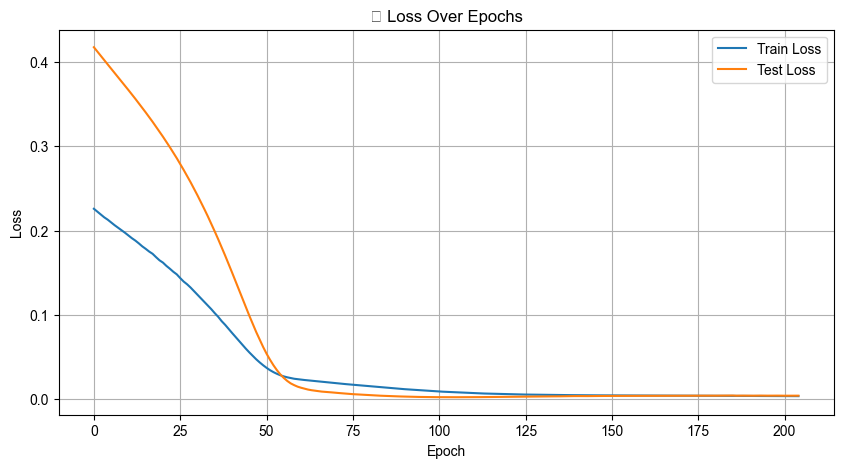

In [566]:
# ----------------------------
# Training Loop + Evaluation
# ----------------------------

train_losses = []
test_losses = []

BEST_LOSS = float("inf")
PATIENCE_COUNTER = 0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        # Reshape input to match LSTM expected input shape: (batch_size, sequence_length, input_size)
        # Ensure input shape matches LSTM expected input shape: (batch_size, sequence_length, input_size)
        # No need to unsqueeze here as the input is already in the correct shape

        preds = model(xb)  # should be shape: (batch_size, 1)

        # Ensure both preds and yb have the same shape
        if preds.ndim == 1:
            preds = preds.unsqueeze(1)  
        if yb.ndim == 1:
            yb = yb.unsqueeze(1)  

        loss = loss_fn(preds, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Average training loss
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ----------------------
    # Evaluate on Test Data
    # ----------------------
    model.eval()
    with torch.no_grad():
        y_pred_test = model(X_test.to(device))
        test_loss = loss_fn(y_pred_test, y_test.to(device)).item()
        test_losses.append(test_loss)

        # Early Stopping Logic
        if test_loss < BEST_LOSS:
            BEST_LOSS = test_loss
            PATIENCE_COUNTER = 0
            best_model_state = model.state_dict()
        else:
            PATIENCE_COUNTER += 1

        if PATIENCE_COUNTER >= PATIENCE:
            print(f"Early stopping at epoch {epoch} — no improvement for {PATIENCE} epochs.")
            break

    # Logging
    if epoch % 100 == 0 or epoch == EPOCHS - 1:
        print(f"Epoch {epoch:03d} | Train Loss: {avg_train_loss:.4f} | Test Loss: {test_loss:.4f} | Best Test Loss: {BEST_LOSS:.4f}")

# Load the best model state after training
model.load_state_dict(best_model_state)

# ----------------------------
# Plot Loss Curve
# ----------------------------
plt.rcParams['font.family'] = 'Arial'  # Set font family before plotting
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.title("📉 Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


In [567]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test.to(device)).cpu().numpy()
    y_true = y_test.cpu().numpy()
    y_pred = target_scaler.inverse_transform(y_pred)
    y_true = target_scaler.inverse_transform(y_true)

In [568]:
def forecast(model, initial_sequence, steps):
    model.eval()
    predictions = []
    current_sequence = initial_sequence.clone()

    for _ in range(steps):
        with torch.no_grad():
            # Make a prediction
            pred = model(current_sequence.unsqueeze(0))  # Add batch dimension
            pred = pred.squeeze(0)  # Remove batch dimension from the output
            if pred[0].item() > 1.0 or pred[0].item() < 0.0:
                print(f"Drifted prediction at step {_}: {pred[0].item()}")
            pred = torch.clamp(pred, min=0.0, max=1.0)  # ensure within scaler range
            

            # Append the prediction to the list
            predictions.append(pred.item())

            # Update the sequence: remove the oldest value and append the new prediction
            pred = pred.repeat(current_sequence.shape[1]).unsqueeze(0)  # Repeat pred to match the number of features
            current_sequence = torch.cat((current_sequence[1:], pred), dim=0)

    return predictions


# Use last known sequence from test set
initial_sequence = X_test[-1].squeeze()  # shape: (LAG_DAYS,)
future_predictions = forecast(model, initial_sequence, steps=10)
future_predictions = target_scaler.inverse_transform(
    np.array(future_predictions).reshape(-1, 1)
).flatten()



Drifted prediction at step 6: 1.0037211179733276
Drifted prediction at step 7: 1.0274720191955566
Drifted prediction at step 8: 1.0465525388717651
Drifted prediction at step 9: 1.0649811029434204


In [569]:
print("y_pred shape:", y_pred.shape)
print("Sample predictions:", y_pred[:5].flatten())

# Reset index to access 'dates' as a column
df_reset = df.reset_index()

# Get the last date in your dataset
last_date = df_reset["dates"].max()

# Create future dates matching forecast steps
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=len(future_predictions), freq="D")

# Get last N true points
N = 30
recent_dates = df_reset["dates"].iloc[-N:]
recent_values = target_scaler.inverse_transform(y_test.cpu().numpy())[-N:]  # if scaled


# Combine with forecast
fig = go.Figure()
fig.add_trace(go.Scatter(x=recent_dates, y=recent_values.flatten(), mode='lines', name='Recent Observations'))
fig.add_trace(go.Scatter(x=future_dates, y=future_predictions, mode='lines+markers', name='Forecast'))

fig.update_layout(
    title="Last Observations + 10-Step Forecast",
    xaxis_title="Date",
    yaxis_title="Observations",
    template="plotly_white"
)
fig.show()



y_pred shape: (198, 1)
Sample predictions: [153.81761 154.33897 154.8094  154.71552 154.58427]


/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/_plotly_utils/basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



In [570]:
# actual vs predicted
# Ensure all arrays have the same length
min_length = min(len(recent_dates), len(recent_values.flatten()), len(future_dates), len(future_predictions))

data = pd.DataFrame({
	"recent_dates": recent_dates[-min_length:],  # Trim to match the minimum length
	"recent_values": recent_values.flatten()[-min_length:],  # Trim to match the minimum length
	"future_dates": future_dates[:min_length],  # Trim to match the minimum length
	"future_predictions": future_predictions[:min_length]  # Trim to match the minimum length
})
print(data.head(10))

    recent_dates  recent_values future_dates  future_predictions
983   2027-09-18     146.754684   2027-09-28          155.036583
984   2027-09-19     139.970871   2027-09-29          156.782657
985   2027-09-20     146.867340   2027-09-30          158.781317
986   2027-09-21     139.126877   2027-10-01          161.094762
987   2027-09-22     150.263367   2027-10-02          163.514089
988   2027-09-23     155.715271   2027-10-03          165.984122
989   2027-09-24     156.401413   2027-10-04          168.407642
990   2027-09-25     152.342422   2027-10-05          168.407642
991   2027-09-26     146.416809   2027-10-06          168.407642
992   2027-09-27     143.495499   2027-10-07          168.407642


In [571]:
#test prediction accuracy
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Ensure y_true and y_pred have the same length
min_length = min(len(y_true), len(y_pred))

# Calculate metrics
mae = mean_absolute_error(y_true[:min_length].flatten(), y_pred[:min_length].flatten())
mse = mean_squared_error(y_true[:min_length].flatten(), y_pred[:min_length].flatten())
rmse = np.sqrt(mse)
r2 = r2_score(y_true[:min_length].flatten(), y_pred[:min_length].flatten())
mape = np.mean(np.abs((y_true[:min_length] - y_pred[:min_length]) / y_true[:min_length])) * 100


# Determine if the model is performing well
is_low_mae = mae < 10  # Example threshold for low MAE
is_high_r2 = r2 > 0.8  # Example threshold for high R2 score
is_low_mape = mape < 10  # Example threshold for low MAPE
performance = "Good" if is_low_mae and is_high_r2 and is_low_mape else "Needs Improvement"

# Print metrics in a dataframe
metrics_df = pd.DataFrame({
    "Test Metric": ["MAE", "MSE", "RMSE", "R2", "MAPE","Performance"],
    "Test Value": [mae, mse, rmse, r2, mape, performance]
})
print(metrics_df)

   Test Metric         Test Value
0          MAE           7.388719
1          MSE          77.926788
2         RMSE           8.827615
3           R2            0.52128
4         MAPE           6.055912
5  Performance  Needs Improvement


In [572]:
# Evaluate on a true forecast horizon
# Use y_true for the true future values and slice it to match the forecast horizon
true_future = y_true.flatten()[-len(future_predictions):]  # Extract the true future values
mae_forecast = mean_absolute_error(true_future[:N], future_predictions[:N]) # N = 10
mse_forecast = mean_squared_error(true_future[:N], future_predictions[:N])
rmse_forecast = np.sqrt(mse_forecast)
r2_forecast = r2_score(true_future[:N], future_predictions[:N])
mape_forecast = np.mean(np.abs((true_future[:N] - future_predictions[:N]) / true_future[:N])) * 100
# Print forecast metrics
forecast_metrics_df = pd.DataFrame({
    "Forecast Metric": ["MAE", "MSE", "RMSE", "R2", "MAPE"],
    "Forecast Value": [mae_forecast, mse_forecast, rmse_forecast, r2_forecast, mape_forecast]
})
forecast_metrics_df["Forecast Value"] = forecast_metrics_df["Forecast Value"].apply(lambda x: round(x, 4))
forecast_quality = "Good" if mae_forecast < 10 and mape_forecast < 10 else "Needs Improvement"
forecast_metrics_df.loc[len(forecast_metrics_df)] = ["Performance", forecast_quality]
print(forecast_metrics_df)

import plotly.graph_objects as go

# Create an interactive plot using Plotly
fig = go.Figure()

# Add true future values
fig.add_trace(go.Scatter(
    y=true_future[:N],
    mode='lines+markers',
    name='True Future',
    marker=dict(symbol='circle', size=8),
    line=dict(color='blue')
))

# Add forecasted values
fig.add_trace(go.Scatter(
    y=future_predictions[:N],
    mode='lines+markers',
    name='Forecast',
    marker=dict(symbol='x', size=8),
    line=dict(color='red')
))

# Update layout for better interactivity
fig.update_layout(
    title="📈 Interactive Forecast vs. Actual (Next N Days)",
    xaxis_title="Day",
    yaxis_title="Observations",
    xaxis=dict(showgrid=True),
    yaxis=dict(showgrid=True),
    legend_title="Legend",
    template="plotly_white"
)

# Show the interactive plot
fig.show()


  Forecast Metric     Forecast Value
0             MAE             15.747
1             MSE            276.324
2            RMSE             16.623
3              R2            -7.5757
4            MAPE            10.7571
5     Performance  Needs Improvement


#save the dataframe to a csv file
params.to_csv("/Users/jaytlinaskew/GitRepository/TimeSeries-Analysis/data/Performance_Data/Neural_Networks/Regression/NextObserved.csv", index=False)